# Action Recognition  Project

In [1]:
# =============Step 1: Library Import =============
from pathlib import Path
from collections import Counter

# Library for data manipulation
import cv2
import numpy as np

# Library for DNN modeling   
import torch 
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18, ResNet18_Weights

# Library for visualization
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm   

c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\io\image.py:14: UserWarning: Failed to load image Python extension: 'Could not find module 'C:\Users\Lenovo\AppData\Local\Programs\Python\Python310\Lib\site-packages\torchvision\image.pyd' (or one of its dependencies). Try using the full path with constructor syntax.'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
#=============Step 2: Find the Data Directories =============

def data_layout(project_dir):
    """
    This function searches for the 'UCF-101' and 'UCF-101-TrainTestlist' directories within the project directory in a relative way.
    It returns the paths to these directories if found, or raises an error if they are not
    """
    data_candiates = [path for path in project_dir.rglob('UCF-101') if path.is_dir()]
    split_candidates = [path for path in project_dir.rglob('UCF-101-TrainTestlist') if path.is_dir()]
    if not data_candiates:
        raise FileNotFoundError("Could not find 'UCF-101' directory in the project.")
    if not split_candidates:
        raise FileNotFoundError("Could not find 'UCF-101-TrainTestlist' directory in the project.")
    return data_candiates[0], split_candidates[0]

PROJECT_DIR = Path.cwd()
DATA_DIR, SPLIT_DIR = data_layout(PROJECT_DIR)
print(f"Data directory: {DATA_DIR}")
print(f"Split directory: {SPLIT_DIR}")



Data directory: e:\2026SpringSemester\2_MachineLearning\Project\Local\OriginalData\UCF-101
Split directory: e:\2026SpringSemester\2_MachineLearning\Project\Local\OriginalData\UCF-101-TrainTestlist


Number of classes: 101
First 5 Classes: ['ApplyEyeMakeup', 'ApplyLipstick', 'Archery', 'BabyCrawling', 'BalanceBeam']
Number of video files: 13320
Sample video: e:\2026SpringSemester\2_MachineLearning\Project\Local\OriginalData\UCF-101\ApplyEyeMakeup\v_ApplyEyeMakeup_g01_c01.avi
frame count, fps, width, height: 164, 25.0, 320, 240


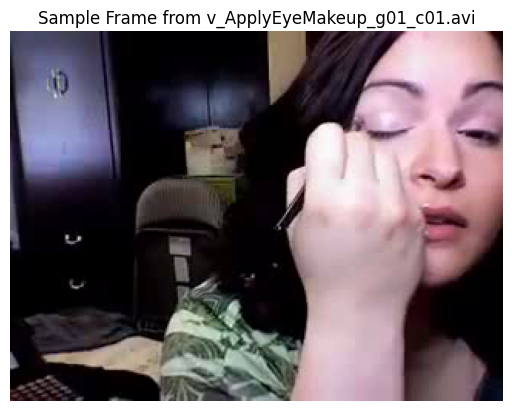

In [3]:
#==============Step 3: File Understanding =============
class_names = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()]) # How many classes and what are they?
print(f"Number of classes: {len(class_names)}")
print(f"First 5 Classes: {class_names[:5]}")

video_files = list(DATA_DIR.rglob("*.avi")) # How many video files are there?
print(f"Number of video files: {len(video_files)}")

# Explore one video file to understand its structure
sample_video_path = video_files[0]
cap = cv2.VideoCapture(str(sample_video_path))  #return a video capture object that can be used to read frames from the video file

if not cap.isOpened():
    raise IOError(f"Cannot open video file: {sample_video_path}")

frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))    

print(f"Sample video: {sample_video_path}")
print(f"frame count, fps, width, height: {frame_count}, {fps}, {width}, {height}")

success, frame = cap.read()
if success:
    type(frame)
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    plt.axis('off')
    plt.title(f"Sample Frame from {sample_video_path.name}")
    plt.show()

cap.release()    

In [4]:
#=============Step 4: Modeling Configuration and Manifest=============
NUM_FRAMES = 8
IMAGE_SIZE = 112

BATCH_SIZE = 5
NUM_EPOCHS = 3
LEARNING_RATE = 1e-3

SPLIT_ID = 1 # using official split method 1 for training
VAL_RATIO = 0.2

NUM_SELECTED_CLASSES = len(class_names)
selected_classes = class_names[:NUM_SELECTED_CLASSES]
NUM_SELECTED_CLASSES = len(selected_classes)

print(f"Number of classes used for training: {NUM_SELECTED_CLASSES}")
print(f"Class preview: {selected_classes[:min(10, NUM_SELECTED_CLASSES)]}")

def build_manifest_from_split(split_dir, data_dir, selected_classes, method):
    """
    Read official train/test split file and build:
    (full_video_path, label, class_name)
    """
    if method == "train":
        split_file = split_dir / f"trainlist{SPLIT_ID:02d}.txt"
    elif method == "test":
        split_file = split_dir / f"testlist{SPLIT_ID:02d}.txt"
    else:
        raise ValueError("method must be 'train' or 'test'")

    if not split_file.exists():
        raise FileNotFoundError(f"Split file not found: {split_file}")

    selected_set = set(selected_classes)
    class_to_label = {
        class_name: idx
        for idx, class_name in enumerate(selected_classes)
    }

    manifest = []

    with open(split_file, "r") as f:
        for line in f:
            relative_path = line.strip().split()[0]
            class_name = relative_path.split("/")[0]

            if class_name not in selected_set:
                continue

            full_video_path = data_dir / relative_path
            label = class_to_label[class_name]

            if full_video_path.exists():
                manifest.append((full_video_path, label, class_name))
            else:
                print(f"Warning: Video file not found: {full_video_path}")

    return manifest

train_files = build_manifest_from_split(SPLIT_DIR, DATA_DIR, selected_classes, method="train")
test_files = build_manifest_from_split(SPLIT_DIR, DATA_DIR, selected_classes, method="test")

print(f"Train manifest videos: {len(train_files)}")
print(f"Test manifest videos: {len(test_files)}")
print(f"First train manifest entry: {train_files[0]}")
print(f"First test manifest entry: {test_files[0]}")


Number of classes used for training: 101
Class preview: ['ApplyEyeMakeup', 'ApplyLipstick', 'Archery', 'BabyCrawling', 'BalanceBeam', 'BandMarching', 'BaseballPitch', 'Basketball', 'BasketballDunk', 'BenchPress']
Train manifest videos: 9537
Test manifest videos: 3783
First train manifest entry: (WindowsPath('e:/2026SpringSemester/2_MachineLearning/Project/Local/OriginalData/UCF-101/ApplyEyeMakeup/v_ApplyEyeMakeup_g08_c01.avi'), 0, 'ApplyEyeMakeup')
First test manifest entry: (WindowsPath('e:/2026SpringSemester/2_MachineLearning/Project/Local/OriginalData/UCF-101/ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c01.avi'), 0, 'ApplyEyeMakeup')


In [5]:
#=============Step 5: Train and validate set split=============
import random
import re
from collections import defaultdict

def extract_group_id(video_path):
    """
    Extract group ID from the video path using regex.
    The group ID is typically in the format 'gXX' where XX is a number.
    """
    match = re.search(r'g\d+', Path(video_path).name)
    return match.group(0) if match else None

def split_train_val_by_group(train_files, val_ratio, seed):
    grouped_videos = defaultdict(list)
    
    for video in train_files:
        video_path, label, class_name = video
        group_id = extract_group_id(video_path)
        if group_id is None:
            raise ValueError(f"Could not extract group ID from video path: {video_path}")
        
        group_key = (class_name, group_id)
        grouped_videos[group_key].append(video)
        
    group_keys = list(grouped_videos.keys())
    rng = random.Random(seed)
    rng.shuffle(group_keys)
    
    num_val_groups = max(1, int(len(group_keys) * val_ratio))  
    val_group_keys = set(group_keys[:num_val_groups])  
    
    train_set = []
    val_set = []    
    
    for group_key, videos in grouped_videos.items():
        if group_key in val_group_keys:
            val_set.extend(videos)
        else:
            train_set.extend(videos)

    return train_set, val_set

train_set, val_set = split_train_val_by_group(train_files, VAL_RATIO, seed=42)
print(f"first one entry in train set:{train_set[0]}")
print(f"Number of training samples:{len(train_set)}")
print(f"first one entry in validation set:{val_set[0]}")
print(f"Number of validation samples:{len(val_set)}")

first one entry in train set:(WindowsPath('e:/2026SpringSemester/2_MachineLearning/Project/Local/OriginalData/UCF-101/ApplyEyeMakeup/v_ApplyEyeMakeup_g08_c01.avi'), 0, 'ApplyEyeMakeup')
Number of training samples:7611
first one entry in validation set:(WindowsPath('e:/2026SpringSemester/2_MachineLearning/Project/Local/OriginalData/UCF-101/ApplyEyeMakeup/v_ApplyEyeMakeup_g13_c01.avi'), 0, 'ApplyEyeMakeup')
Number of validation samples:1926


Sample count by split:
     train: 7611 videos
validation: 1926 videos
      test: 3783 videos

Class distribution summary:
Classes: 101
Minimum videos per class: 100
Maximum videos per class: 167
Mean videos per class: 131.88
Median videos per class: 131.00

Classes with smallest and largest sample counts:
class_name                        train      val     test    total
------------------------------------------------------------------
Skijet                               48       24       28      100
TaiChi                               52       20       28      100
PullUps                              48       24       28      100
PlayingViolin                        64        8       28      100
BreastStroke                         73        0       28      101
PushUps                              56       16       30      102
UnevenBars                           56       20       28      104
PlayingPiano                         56       21       28      105
BalanceBeam          

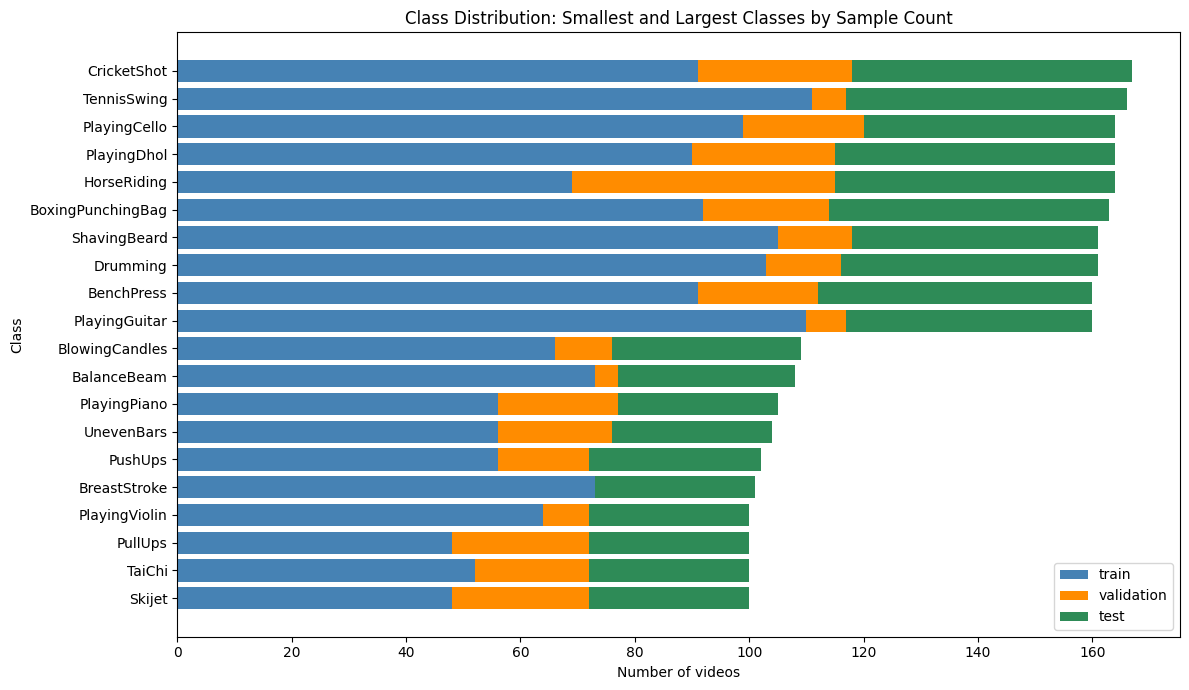

In [6]:
#=============Step 6: Analyze Data Split=============

def count_by_class(samples):
    """Count the number of videos for each class in a split."""
    return Counter(class_name for _, _, class_name in samples)


def groups_by_split(samples):
    """Return class-level group keys to check leakage between splits."""
    group_keys = set()
    for video_path, _, class_name in samples:
        group_id = extract_group_id(video_path)
        group_keys.add((class_name, group_id))
    return group_keys


def select_extreme_indices(values, top_k):
    """Return unique indices from the low and high ends of a sorted array."""
    sorted_indices = np.argsort(values)
    candidate_indices = np.concatenate([sorted_indices[:top_k], sorted_indices[-top_k:]])
    return np.array(list(dict.fromkeys(candidate_indices.tolist())))


def print_distribution_table(indices, class_names, distribution_matrix):
    header = f"{'class_name':<30} {'train':>8} {'val':>8} {'test':>8} {'total':>8}"
    print(header)
    print("-" * len(header))
    for idx in indices:
        train_count = distribution_matrix[0, idx]
        val_count = distribution_matrix[1, idx]
        test_count = distribution_matrix[2, idx]
        total_count = train_count + val_count + test_count
        print(f"{class_names[idx]:<30} {train_count:>8} {val_count:>8} {test_count:>8} {total_count:>8}")


split_samples = {
    "train": train_set,
    "validation": val_set,
    "test": test_files,
}

print("Sample count by split:")
for split_name, samples in split_samples.items():
    print(f"{split_name:>10}: {len(samples)} videos")

class_distribution = {
    split_name: count_by_class(samples)
    for split_name, samples in split_samples.items()
}

distribution_matrix = np.array([
    [class_distribution["train"].get(class_name, 0) for class_name in selected_classes],
    [class_distribution["validation"].get(class_name, 0) for class_name in selected_classes],
    [class_distribution["test"].get(class_name, 0) for class_name in selected_classes],
])

total_counts = distribution_matrix.sum(axis=0)
summary_indices = select_extreme_indices(total_counts, top_k=min(10, len(selected_classes)))

print("\nClass distribution summary:")
print(f"Classes: {len(selected_classes)}")
print(f"Minimum videos per class: {total_counts.min()}")
print(f"Maximum videos per class: {total_counts.max()}")
print(f"Mean videos per class: {total_counts.mean():.2f}")
print(f"Median videos per class: {np.median(total_counts):.2f}")
print("\nClasses with smallest and largest sample counts:")
print_distribution_table(summary_indices, selected_classes, distribution_matrix)

print("\nMissing classes by split:")
for split_name, distribution in class_distribution.items():
    missing_classes = [
        class_name
        for class_name in selected_classes
        if distribution.get(class_name, 0) == 0
    ]
    print(f"{split_name:>10}: {missing_classes if missing_classes else 'none'}")

print("\nGroup overlap check:")
group_sets = {
    split_name: groups_by_split(samples)
    for split_name, samples in split_samples.items()
}

overlap_pairs = [
    ("train", "validation"),
    ("train", "test"),
    ("validation", "test"),
]

for left, right in overlap_pairs:
    overlap = group_sets[left] & group_sets[right]
    if overlap:
        print(f"WARNING: {left} / {right} overlap: {len(overlap)} class-group pairs")
        print(sorted(overlap)[:10])
    else:
        print(f"{left:>10} / {right:<10}: no group overlap")

plot_indices = summary_indices
plot_classes = [selected_classes[i] for i in plot_indices]
plot_train = distribution_matrix[0, plot_indices]
plot_val = distribution_matrix[1, plot_indices]
plot_test = distribution_matrix[2, plot_indices]

y = np.arange(len(plot_classes))
plt.figure(figsize=(12, max(6, len(plot_classes) * 0.35)))
plt.barh(y, plot_train, label="train", color="steelblue")
plt.barh(y, plot_val, left=plot_train, label="validation", color="darkorange")
plt.barh(y, plot_test, left=plot_train + plot_val, label="test", color="seagreen")
plt.yticks(y, plot_classes)
plt.xlabel("Number of videos")
plt.ylabel("Class")
plt.title("Class Distribution: Smallest and Largest Classes by Sample Count")
plt.legend()
plt.tight_layout()
plt.show()


In [7]:
#=============Step 7: preprocessing a single video file=============
def load_video_clip(video_path, num_frames, img_size):
    """
    Load a video clip from a file and preprocess it.
     - video_path: Path to the video file
     - num_frames: Number of frames to sample from the video
     - img_size: Size to which each frame will be resized (img_size x img_size)
     Returns:
        torch.Tensor: Preprocessed video clip
    """
    
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise IOError(f"Cannot open video file: {video_path}")
    
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if total_frames < num_frames:
        raise ValueError(f"Video has only {total_frames} frames, but {num_frames} frames are requested.")
    
    frame_indices = np.linspace(0, total_frames-1, num_frames, dtype=int) #Evenly sample frame based on frame index
    frames = []
    failed_reads = 0
    
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        success, frame = cap.read()
        if not success:
            failed_reads += 1
            if frames:  # If we have already read some frames, we can repeat the last one
                frames.append(frames[-1].copy())
            continue
        
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) # Convert BGR to RGB
        frame_resized = cv2.resize(frame_rgb, (img_size, img_size))
        frame = frame_resized.astype(np.float32) / 255.0 # Normalize channel values to [0, 1]
        frames.append(frame)
        
    cap.release()    
    
    if len(frames) == 0:
        raise ValueError(f"Could not read any frames from video: {video_path}")
    
    while len(frames) < num_frames:
        frames.append(frames[-1].copy()) # If not enough frames, repeat the last frame
    
    clip = np.stack(frames, axis=0) # (num_frames, H, W, C)
    clip = np.transpose(clip, (3, 0, 1, 2)) # (C, num_frames, H, W)
    clip = torch.from_numpy(clip) # Convert to tensor
    
    return clip

sample_video_path = train_set[0][0]  # Get the video path from the first entry in the training set
clip = load_video_clip(sample_video_path, NUM_FRAMES, IMAGE_SIZE)

print("Video path:", sample_video_path)
print("Clip shape(channels, num_frames, height, width):", clip.shape)
print("Clip dtype:", clip.dtype)
print("Min value:", clip.min().item())
print("Max value:", clip.max().item())

Video path: e:\2026SpringSemester\2_MachineLearning\Project\Local\OriginalData\UCF-101\ApplyEyeMakeup\v_ApplyEyeMakeup_g08_c01.avi
Clip shape(channels, num_frames, height, width): torch.Size([3, 8, 112, 112])
Clip dtype: torch.float32
Min value: 0.0
Max value: 0.9960784316062927


In [8]:
#=============Step 8: Create a Pytorch Dataset to wrap the data============
class VideoDataSet(Dataset):
    def __init__(self, samples, num_frames, img_size):
        """
        samples: List of tuples (video_path, label, class_name)
        """
        self.samples = samples
        self.num_frames =num_frames
        self.img_size = img_size
        
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        video_path, label, class_name = self.samples[idx]
        
        clip = load_video_clip(video_path, self.num_frames, self.img_size)
        
        label = torch.tensor(label, dtype=torch.long)
        
        return clip, label, str(video_path), class_name
    
train_dataset = VideoDataSet(train_set, NUM_FRAMES, IMAGE_SIZE)
val_dataset = VideoDataSet(val_set, NUM_FRAMES, IMAGE_SIZE)
test_dataset = VideoDataSet(test_files, NUM_FRAMES, IMAGE_SIZE) 

# Create DataLoaders for batching
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers = 0
)    

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers = 0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers = 0
)

In [9]:
#=============Step 9: Frame-level CNN Baseline Model=============
class FrameLevelCNN(nn.Module):
    def __init__(self, num_classes):
        super(FrameLevelCNN, self).__init__()
        self.cnn = resnet18(weights=ResNet18_Weights.DEFAULT) # Load ResNet-18 with pretrained weights  
        self.cnn.fc = nn.Linear(self.cnn.fc.in_features, num_classes)
        
    def forward(self, x): #This method is for calculating the input and output of the model automatically
        batch_size, channels, num_frames, height, width = x.shape
        x = x.permute(0, 2, 1, 3, 4) # (B, C, num_frames, H, W) ->(B,num_frames, C, H, W)
        x = x.reshape(batch_size*num_frames, channels,height, width) 
           
        frame_outputs = self.cnn(x) # (B*num_frames, num_classes)
        frame_outputs = frame_outputs.reshape(batch_size, num_frames, -1) # (B, num_frames, num_classes)
        
        # Average frame-level predictions to get video-level prediction
        video_outputs = frame_outputs.mean(dim=1) # (B, num_classes)
        return video_outputs
    
model = FrameLevelCNN(num_classes = NUM_SELECTED_CLASSES)
# Take one batch from the train_loader to check the data flow through the model
clips, labels, video_path, class_name =  next(iter(train_loader))
print("Clip shape:", clips.shape)
print("Labels shape:", labels.shape)

outputs = model(clips) # equal to outputs = model.forward(clips) 
print("Output shape:", outputs.shape)
  

Clip shape: torch.Size([5, 3, 8, 112, 112])
Labels shape: torch.Size([5])
Output shape: torch.Size([5, 101])


In [10]:
#=============Step 10: Training Frame-level CNN Model=============
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0.0
    train_correct = 0 
    train_total = 0
    
    for clips, labels, _, _ in tqdm(train_loader, desc=f"Epoch{epoch+1}/{NUM_EPOCHS}-Train"):
        optimizer.zero_grad()
        outputs = model(clips)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * labels.size(0)
        
        predicted = outputs.argmax(dim=1)
        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)
        
    train_loss = train_loss / train_total
    train_acc = train_correct / train_total
    
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for clips, labels, _, _ in tqdm(val_loader, desc=f"Epoch{epoch+1}/{NUM_EPOCHS}-Val"):
            outputs = model(clips)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * labels.size(0)
            
            predicted = outputs.argmax(dim=1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)    
            
    val_loss = val_loss / val_total
    val_acc = val_correct / val_total   
    
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)      
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )         

Epoch1/3-Val: 100%|██████████| 386/386 [02:57<00:00,  2.17it/s]


Epoch 1/3 - Train Loss: 4.4155, Train Acc: 0.0507 - Val Loss: 7.9131, Val Acc: 0.0732


Epoch2/3-Val: 100%|██████████| 386/386 [02:53<00:00,  2.23it/s]


Epoch 2/3 - Train Loss: 3.6332, Train Acc: 0.1478 - Val Loss: 5.9129, Val Acc: 0.1303


Epoch3/3-Val: 100%|██████████| 386/386 [02:53<00:00,  2.23it/s]

Epoch 3/3 - Train Loss: 2.9727, Train Acc: 0.2607 - Val Loss: 4.9591, Val Acc: 0.1537


Testing Frame-level CNN: 100%|██████████| 757/757 [05:34<00:00,  2.26it/s]


Frame-level CNN Test Accuracy: 0.1853
Frame-level CNN Confusion Matrix Shape: (101, 101)

Frame-level CNN Per-class Accuracy Summary:
Mean per-class accuracy: 0.1831
Minimum per-class accuracy: 0.0000
Maximum per-class accuracy: 0.8293
Class                            Accuracy
-------------------------------------------
ApplyEyeMakeup                     0.0000
Archery                            0.0000
BlowingCandles                     0.0000
BoxingSpeedBag                     0.0000
CuttingInKitchen                   0.0000
PlayingDhol                        0.0000
Nunchucks                          0.0000
PizzaTossing                       0.0000
Kayaking                           0.0000
MilitaryParade                     0.0000
BalanceBeam                        0.5806
BaseballPitch                      0.6047
ParallelBars                       0.6216
BasketballDunk                     0.6216
Bowling                            0.6512
Surfing                            0.6667
IceDan

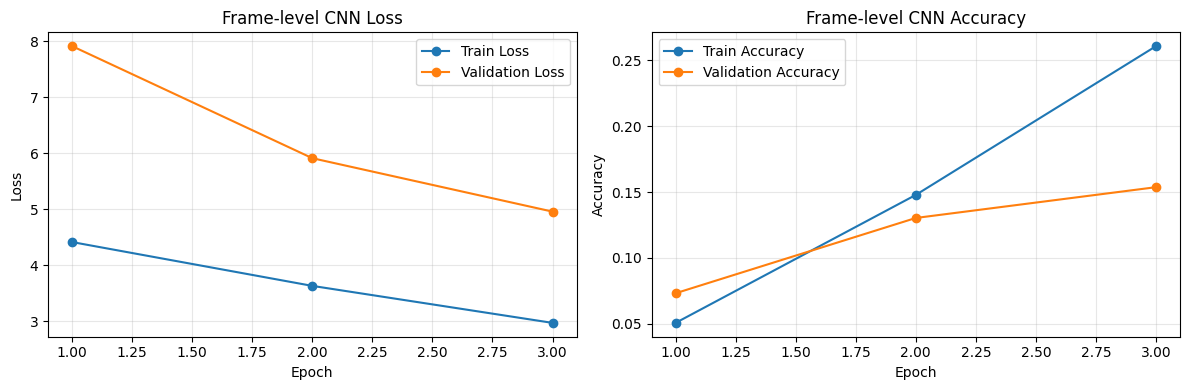

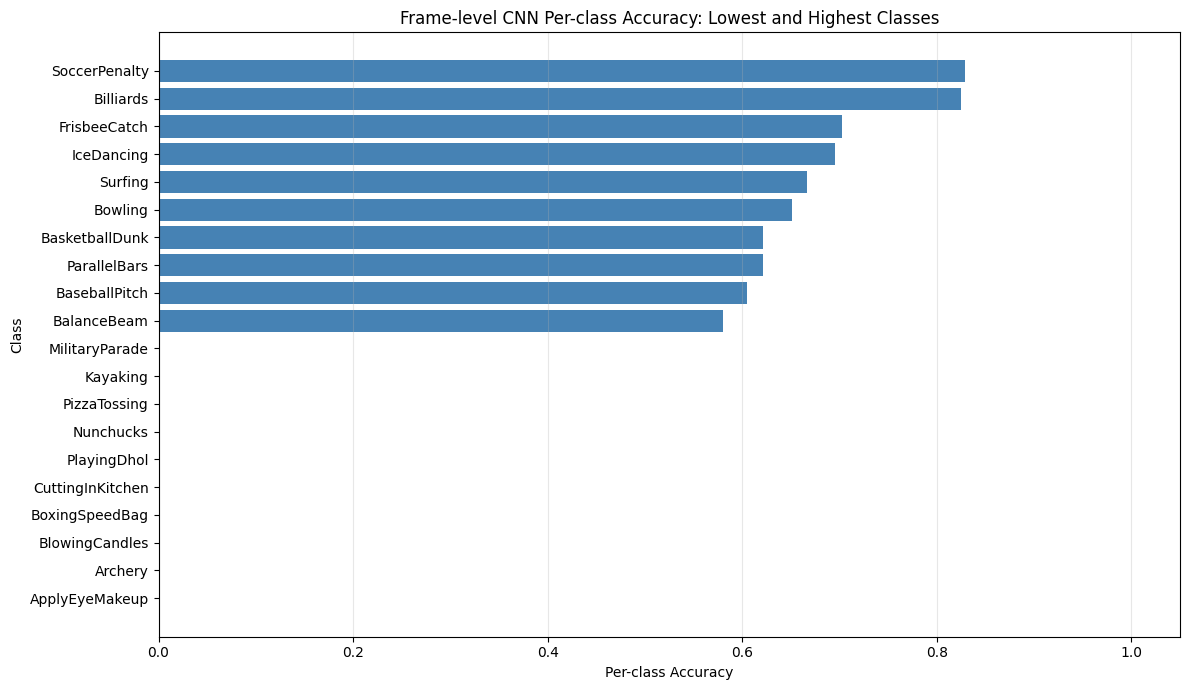

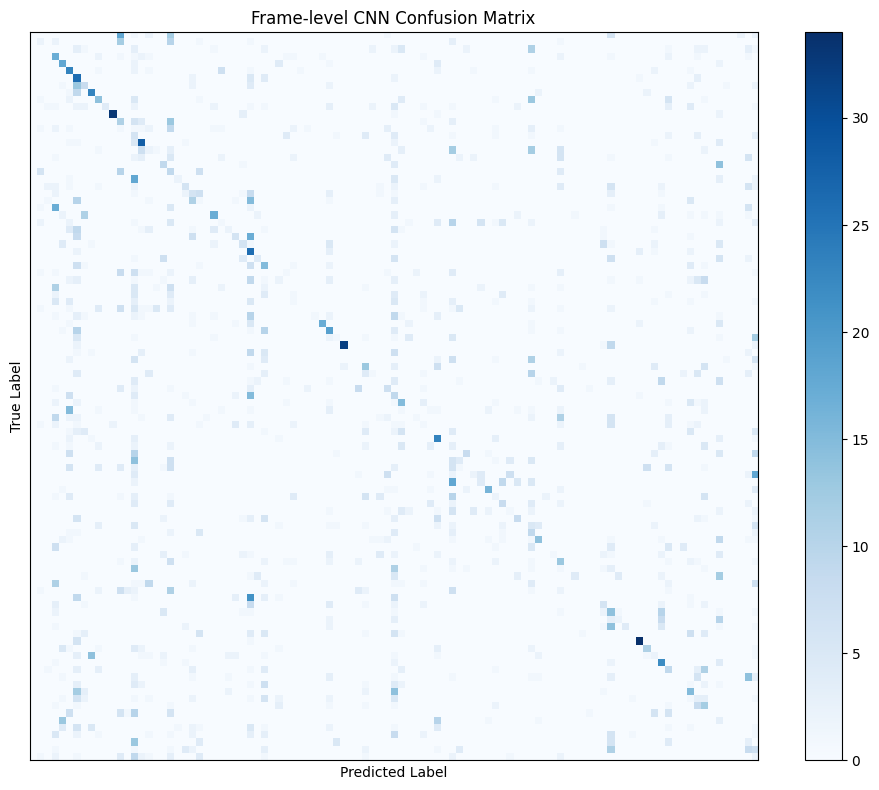

In [11]:
#=============Step 11: Evaluate Frame-level CNN on Test Set=============

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
    for clips, labels, video_paths, class_names_batch in tqdm(test_loader, desc="Testing Frame-level CNN"):

        outputs = model(clips)
        predictions = outputs.argmax(dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

test_acc = (all_predictions == all_labels).mean()
print(f"Frame-level CNN Test Accuracy: {test_acc:.4f}")

cm = confusion_matrix(all_labels, all_predictions, labels=np.arange(len(selected_classes)))
print("Frame-level CNN Confusion Matrix Shape:", cm.shape)

frame_eval_per_class_acc = []
for class_idx, class_name in enumerate(selected_classes):
    class_mask = all_labels == class_idx
    class_acc = np.nan if class_mask.sum() == 0 else (all_predictions[class_mask] == all_labels[class_mask]).mean()
    frame_eval_per_class_acc.append(class_acc)

frame_eval_per_class_acc = np.array(frame_eval_per_class_acc)
valid_indices = np.where(~np.isnan(frame_eval_per_class_acc))[0]
summary_indices = valid_indices[np.argsort(frame_eval_per_class_acc[valid_indices])]
summary_indices = np.array(list(dict.fromkeys(np.concatenate([summary_indices[:10], summary_indices[-10:]]).tolist())))

print("\nFrame-level CNN Per-class Accuracy Summary:")
print(f"Mean per-class accuracy: {np.nanmean(frame_eval_per_class_acc):.4f}")
print(f"Minimum per-class accuracy: {np.nanmin(frame_eval_per_class_acc):.4f}")
print(f"Maximum per-class accuracy: {np.nanmax(frame_eval_per_class_acc):.4f}")
print(f"{'Class':<30} {'Accuracy':>10}")
print("-" * 43)
for idx in summary_indices:
    print(f"{selected_classes[idx]:<30} {frame_eval_per_class_acc[idx]:>10.4f}")

# Visualize the results
## Training Curves
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Frame-level CNN Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], marker="o", label="Train Accuracy")
plt.plot(epochs, history["val_acc"], marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Frame-level CNN Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Per-class accuracy summary
plot_classes = [selected_classes[i] for i in summary_indices]
plot_acc = frame_eval_per_class_acc[summary_indices]

plt.figure(figsize=(12, max(6, len(plot_classes) * 0.35)))
plt.barh(plot_classes, plot_acc, color="steelblue")
plt.xlabel("Per-class Accuracy")
plt.ylabel("Class")
plt.title("Frame-level CNN Per-class Accuracy: Lowest and Highest Classes")
plt.xlim(0, 1.05)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## Confusion Matrix
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Frame-level CNN Confusion Matrix")
plt.colorbar()
plt.xticks([])
plt.yticks([])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [12]:
#================Step 12: temporal 3D CNN Model================
class C3DLikeCNN(nn.Module):
    def __init__(self, num_classes):
        super(C3DLikeCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv3d(in_channels=3, out_channels=32, kernel_size=(3, 3, 3), padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(1, 2, 2)),
            
            nn.Conv3d(in_channels=32, out_channels=64, kernel_size=(3, 3, 3), padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),      
            nn.MaxPool3d(kernel_size=(2, 2, 2)),
            
            nn.Conv3d(64, 128, kernel_size=(3, 3, 3), padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(2, 2, 2)),

            nn.Conv3d(128, 256, kernel_size=(3, 3, 3), padding=1),
            nn.BatchNorm3d(256),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool3d((1, 1, 1))
        )    
        
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256, num_classes)
        )
    
    def forward(self,x):
        x = self.features(x)
        x = x.flatten(1)
        x = self.classifier(x)
        return x
    
c3d_model = C3DLikeCNN(num_classes=NUM_SELECTED_CLASSES)        

clips, labels, video_path, class_name =  next(iter(train_loader))
c3d_outputs = c3d_model(clips)

print("Input shape to C3D-like CNN:", clips.shape)
print("C3D-like CNN Output shape:", c3d_outputs.shape)  


Input shape to C3D-like CNN: torch.Size([5, 3, 8, 112, 112])
C3D-like CNN Output shape: torch.Size([5, 101])


In [13]:
#================Step 13: Train C3D-like CNN Model================
c3d_criterion = nn.CrossEntropyLoss()
c3d_optimizer = torch.optim.Adam(c3d_model.parameters(), lr=LEARNING_RATE)
c3d_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

C3D_NUMBER_EPOCHS = 10
for epoch in range(C3D_NUMBER_EPOCHS):
    c3d_model.train()
    train_loss = 0.0
    train_correct = 0 
    train_total = 0
    
    for clips, labels, _, _ in tqdm(train_loader, desc=f"C3D Epoch{epoch+1}/{C3D_NUMBER_EPOCHS}-Train"):
        c3d_optimizer.zero_grad()
        c3d_outputs = c3d_model(clips)
        loss = c3d_criterion(c3d_outputs, labels)
        loss.backward()
        c3d_optimizer.step()
        train_loss += loss.item() * labels.size(0)
        
        predicted = c3d_outputs.argmax(dim=1)
        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)
        
    train_loss = train_loss / train_total
    train_acc = train_correct / train_total
    
    c3d_model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for clips, labels, _, _ in tqdm(val_loader, desc=f"C3D Epoch{epoch+1}/{C3D_NUMBER_EPOCHS}-Val"):
            c3d_outputs = c3d_model(clips)
            loss = c3d_criterion(c3d_outputs, labels)
            val_loss += loss.item() * labels.size(0)
            
            predicted = c3d_outputs.argmax(dim=1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)    
            
    val_loss = val_loss / val_total
    val_acc = val_correct / val_total   
    
    c3d_history["train_loss"].append(train_loss)
    c3d_history["train_acc"].append(train_acc)      
    c3d_history["val_loss"].append(val_loss)
    c3d_history["val_acc"].append(val_acc)
    
    print(f"C3D Epoch {epoch+1}/{C3D_NUMBER_EPOCHS} - "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )

C3D Epoch1/10-Val: 100%|██████████| 386/386 [02:31<00:00,  2.55it/s]


C3D Epoch 1/10 - Train Loss: 4.3273, Train Acc: 0.0514 - Val Loss: 4.2810, Val Acc: 0.0685


C3D Epoch2/10-Val: 100%|██████████| 386/386 [02:29<00:00,  2.58it/s]


C3D Epoch 2/10 - Train Loss: 3.8292, Train Acc: 0.1064 - Val Loss: 3.9653, Val Acc: 0.0826


C3D Epoch3/10-Val: 100%|██████████| 386/386 [02:29<00:00,  2.58it/s]


...

C3D Epoch 8/10 - Train Loss: 2.8019, Train Acc: 0.2898 - Val Loss: 3.1228, Val Acc: 0.2404


C3D Epoch9/10-Val: 100%|██████████| 386/386 [02:29<00:00,  2.58it/s]


C3D Epoch 9/10 - Train Loss: 2.6919, Train Acc: 0.3128 - Val Loss: 3.0209, Val Acc: 0.2430


C3D Epoch10/10-Val: 100%|██████████| 386/386 [02:29<00:00,  2.58it/s]

C3D Epoch 10/10 - Train Loss: 2.5681, Train Acc: 0.3387 - Val Loss: 3.0142, Val Acc: 0.2606


Testing C3D-like CNN:   0%|          | 0/757 [00:00<?, ?it/s]

Testing C3D-like CNN: 100%|██████████| 757/757 [04:44<00:00,  2.66it/s]


C3D-like CNN Test Accuracy: 0.2797
C3D-like CNN Confusion Matrix Shape: (101, 101)

C3D-like CNN Per-class Accuracy Summary:
Mean per-class accuracy: 0.2758
Minimum per-class accuracy: 0.0000
Maximum per-class accuracy: 0.9500
Class                            Accuracy
-------------------------------------------
Archery                            0.0000
BodyWeightSquats                   0.0000
JumpingJack                        0.0000
JugglingBalls                      0.0000
HulaHoop                           0.0000
HandstandWalking                   0.0000
PlayingCello                       0.0000
PizzaTossing                       0.0000
MoppingFloor                       0.0000
Nunchucks                          0.0000
BreastStroke                       0.6786
PlayingPiano                       0.6786
Bowling                            0.6977
CliffDiving                        0.7179
Skijet                             0.7500
Punch                              0.7949
SoccerPenalty  

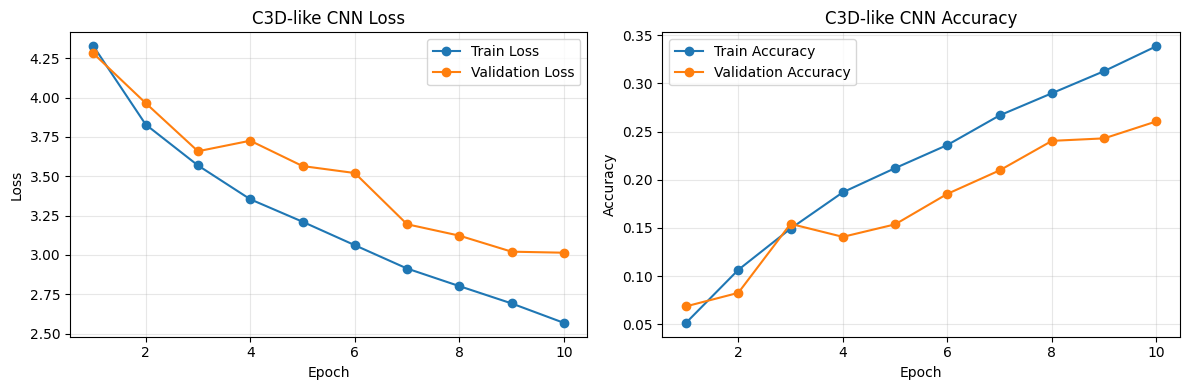

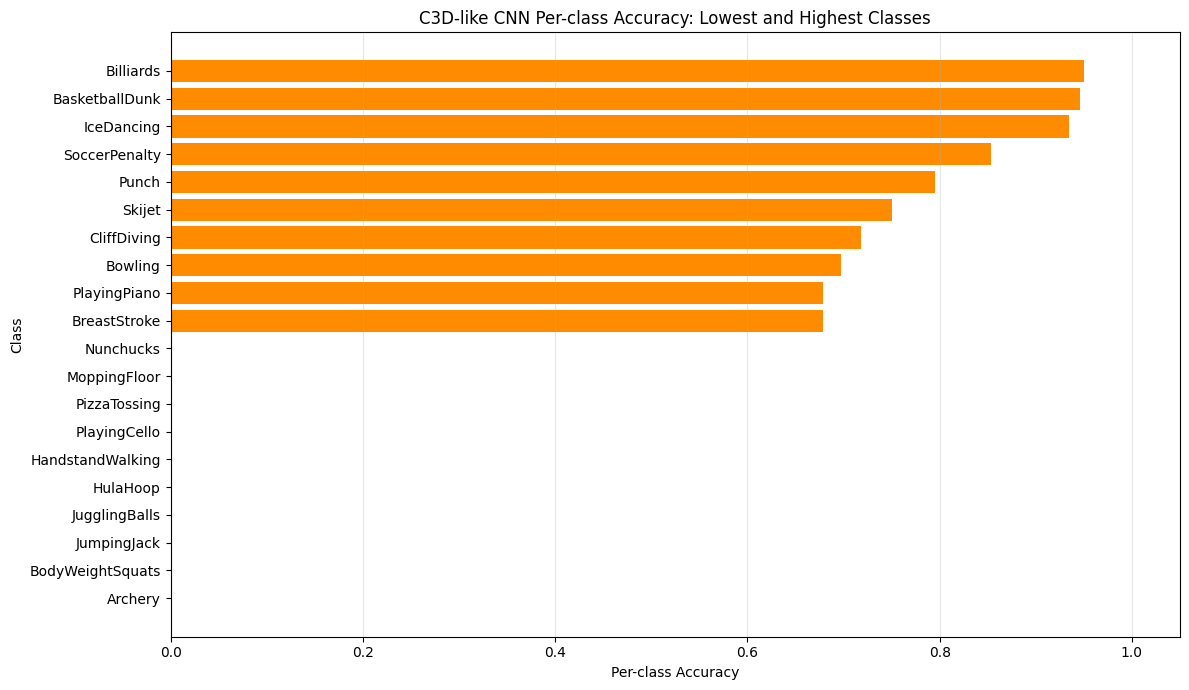

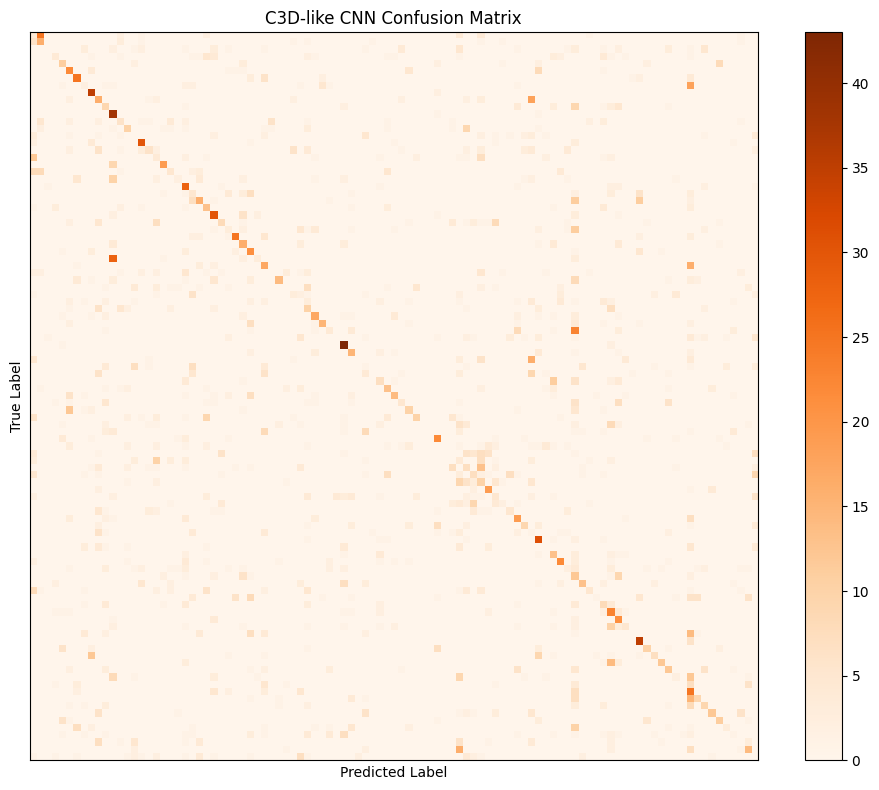

In [14]:
#=============Step 14: Evaluation of C3D-like CNN Model and Visualization=============

c3d_model.eval()

c3d_all_labels = []
c3d_all_predictions = []

with torch.no_grad():
    for clips, labels, video_paths, class_names_batch in tqdm(test_loader, desc="Testing C3D-like CNN"):
        c3d_outputs = c3d_model(clips)
        c3d_predictions = c3d_outputs.argmax(dim=1)

        c3d_all_labels.extend(labels.cpu().numpy())
        c3d_all_predictions.extend(c3d_predictions.cpu().numpy())

c3d_all_labels = np.array(c3d_all_labels)
c3d_all_predictions = np.array(c3d_all_predictions)

c3d_test_acc = (c3d_all_predictions == c3d_all_labels).mean()
print(f"C3D-like CNN Test Accuracy: {c3d_test_acc:.4f}")

c3d_cm = confusion_matrix(c3d_all_labels, c3d_all_predictions, labels=np.arange(len(selected_classes)))
print("C3D-like CNN Confusion Matrix Shape:", c3d_cm.shape)

c3d_per_class_acc = []
for class_idx, class_name in enumerate(selected_classes):
    class_mask = c3d_all_labels == class_idx
    class_acc = np.nan if class_mask.sum() == 0 else (c3d_all_predictions[class_mask] == c3d_all_labels[class_mask]).mean()
    c3d_per_class_acc.append(class_acc)

c3d_per_class_acc = np.array(c3d_per_class_acc)
valid_indices = np.where(~np.isnan(c3d_per_class_acc))[0]
summary_indices = valid_indices[np.argsort(c3d_per_class_acc[valid_indices])]
summary_indices = np.array(list(dict.fromkeys(np.concatenate([summary_indices[:10], summary_indices[-10:]]).tolist())))

print("\nC3D-like CNN Per-class Accuracy Summary:")
print(f"Mean per-class accuracy: {np.nanmean(c3d_per_class_acc):.4f}")
print(f"Minimum per-class accuracy: {np.nanmin(c3d_per_class_acc):.4f}")
print(f"Maximum per-class accuracy: {np.nanmax(c3d_per_class_acc):.4f}")
print(f"{'Class':<30} {'Accuracy':>10}")
print("-" * 43)
for idx in summary_indices:
    print(f"{selected_classes[idx]:<30} {c3d_per_class_acc[idx]:>10.4f}")

# Visualize C3D training curves
c3d_epochs = range(1, len(c3d_history["train_loss"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(c3d_epochs, c3d_history["train_loss"], marker="o", label="Train Loss")
plt.plot(c3d_epochs, c3d_history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("C3D-like CNN Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(c3d_epochs, c3d_history["train_acc"], marker="o", label="Train Accuracy")
plt.plot(c3d_epochs, c3d_history["val_acc"], marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("C3D-like CNN Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Per-class accuracy summary
plot_classes = [selected_classes[i] for i in summary_indices]
plot_acc = c3d_per_class_acc[summary_indices]

plt.figure(figsize=(12, max(6, len(plot_classes) * 0.35)))
plt.barh(plot_classes, plot_acc, color="darkorange")
plt.xlabel("Per-class Accuracy")
plt.ylabel("Class")
plt.title("C3D-like CNN Per-class Accuracy: Lowest and Highest Classes")
plt.xlim(0, 1.05)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Visualize C3D confusion matrix
plt.figure(figsize=(10, 8))
plt.imshow(c3d_cm, interpolation="nearest", cmap="Oranges")
plt.title("C3D-like CNN Confusion Matrix")
plt.colorbar()
plt.xticks([])
plt.yticks([])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


Overall Metrics
Metric                  Frame-CNN    C3D-like CNN
--------------------------------------------------
accuracy                   0.1853          0.2797
macro_precision            0.2147          0.2834
macro_recall               0.1831          0.2758
macro_f1                   0.1606          0.2519
weighted_precision         0.2150          0.2869
weighted_recall            0.1853          0.2797
weighted_f1                0.1630          0.2546

Per-class Accuracy Difference Summary
Classes: 101
Frame-CNN mean per-class accuracy: 0.1831
C3D-like CNN mean per-class accuracy: 0.2758
Mean difference: +0.0927
Class                             Frame-CNN    C3D-like CNN   Difference
---------------------------------------------------------------------------
BabyCrawling                         0.4857          0.1143      -0.3714
JumpRope                             0.3421          0.0263      -0.3158
HorseRiding                          0.3878          0.0816      -0.3061
S

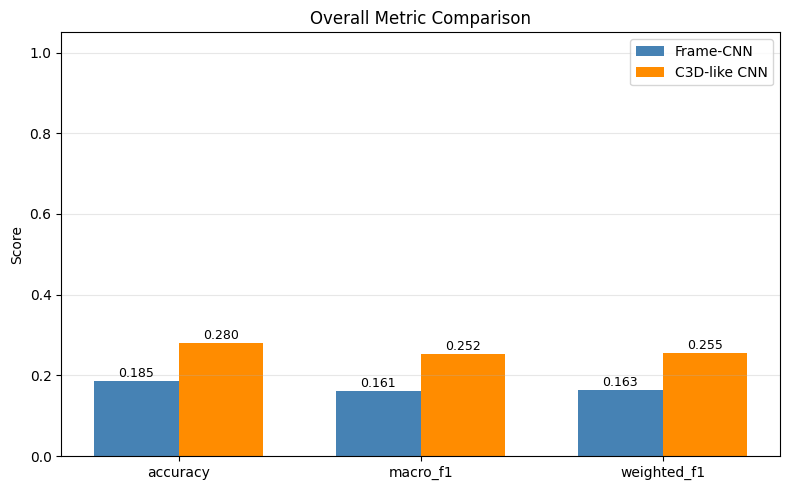

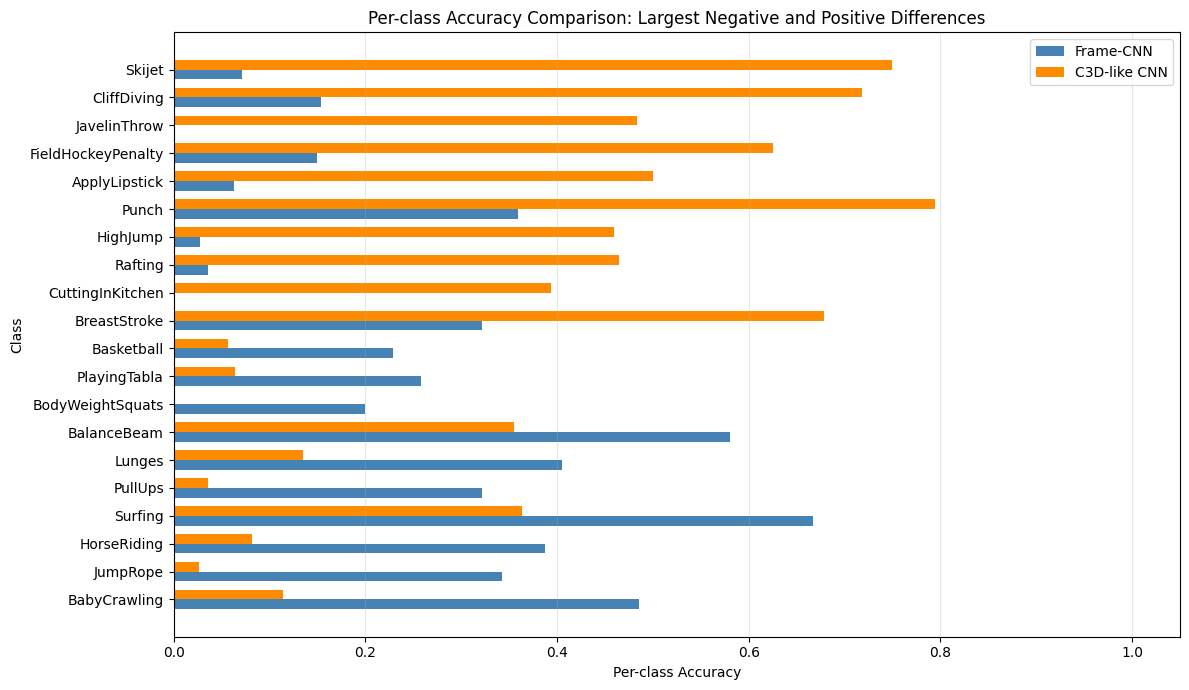

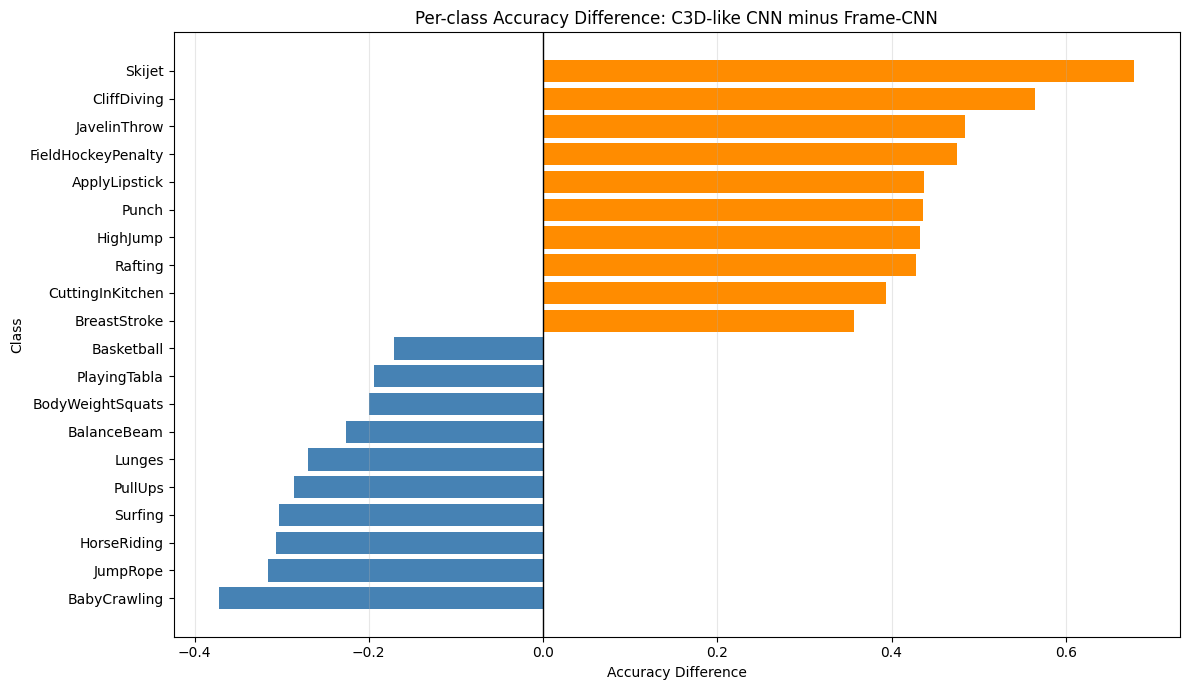

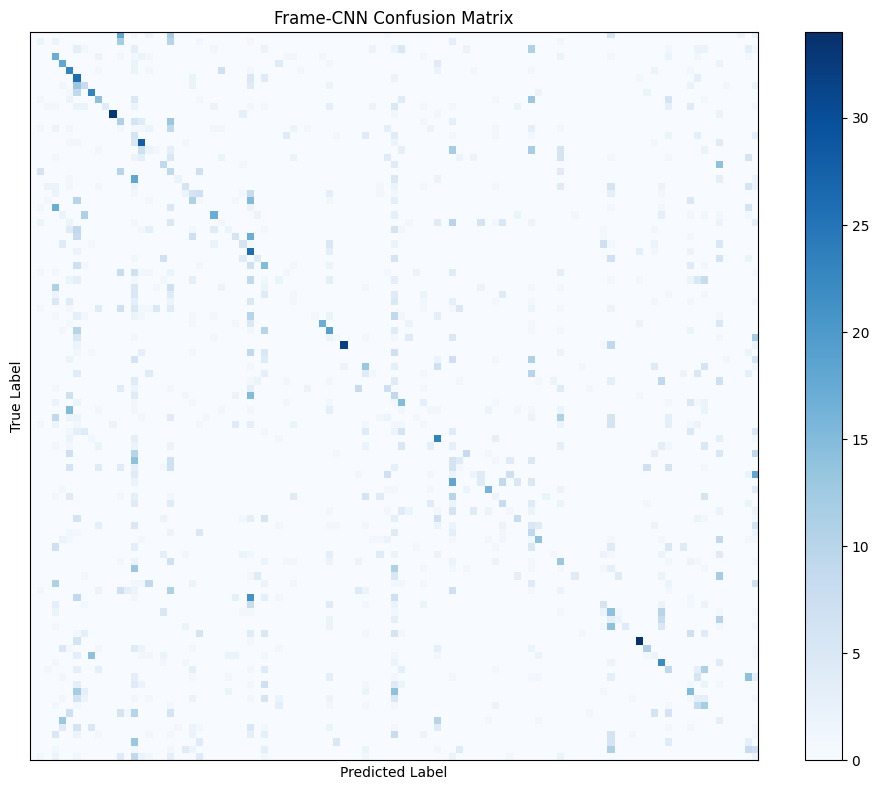

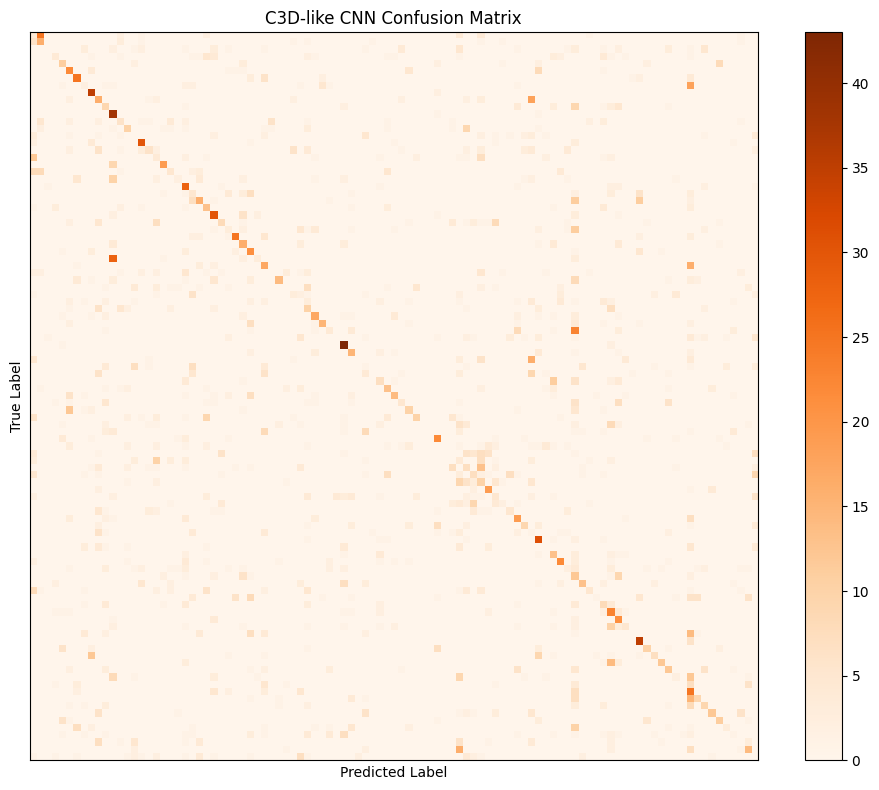

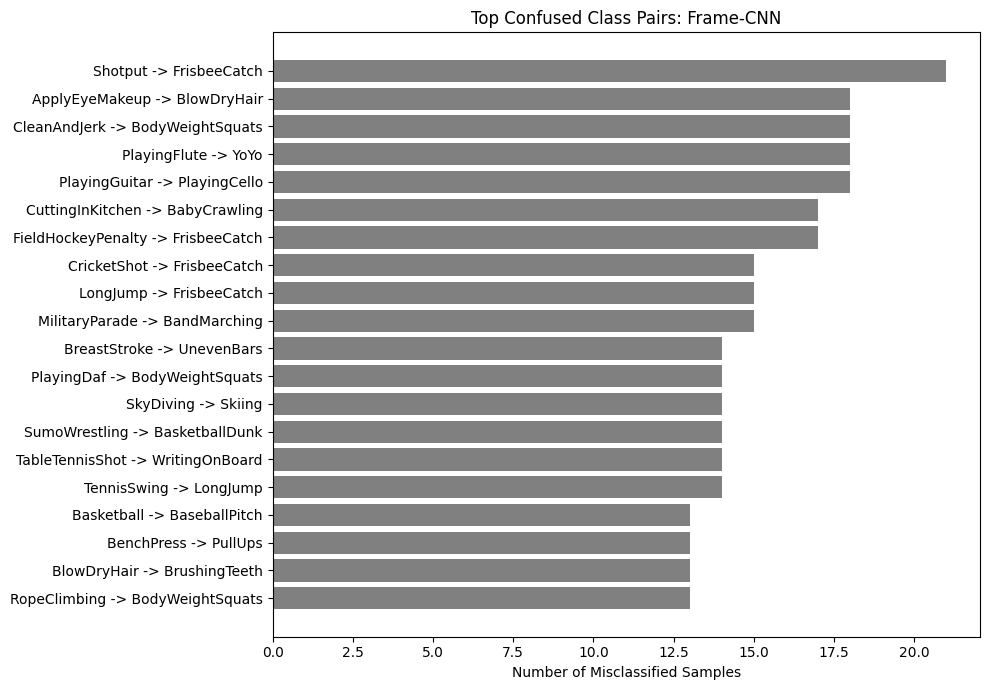

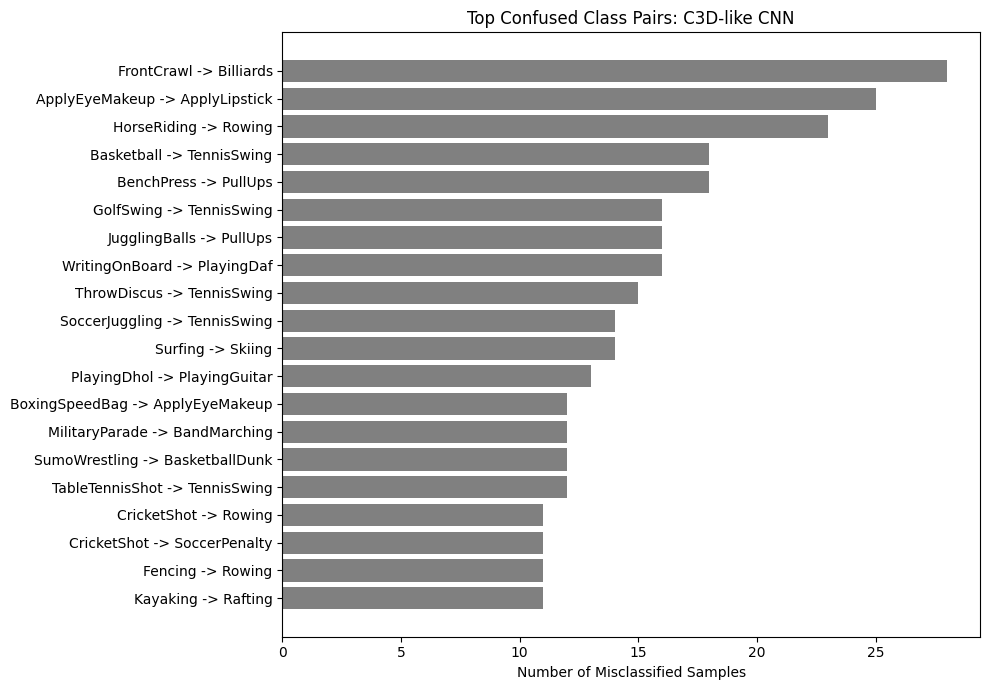

In [15]:
#===============Step 15: Compare the two models and visualize the results================
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

frame_labels = all_labels
frame_preds = all_predictions

c3d_labels = c3d_all_labels
c3d_preds = c3d_all_predictions

num_classes = len(selected_classes)


def compute_summary_metrics(labels, preds):
    accuracy = accuracy_score(labels, preds)

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        labels=np.arange(num_classes),
        average="macro",
        zero_division=0
    )

    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        labels=np.arange(num_classes),
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,
    }


def compute_per_class_accuracy(labels, preds, num_classes):
    per_class_acc = []
    for class_idx in range(num_classes):
        class_mask = labels == class_idx
        class_acc = np.nan if class_mask.sum() == 0 else (preds[class_mask] == labels[class_mask]).mean()
        per_class_acc.append(class_acc)
    return np.array(per_class_acc)


def select_extreme_indices(values, top_k):
    valid_indices = np.where(~np.isnan(values))[0]
    sorted_indices = valid_indices[np.argsort(values[valid_indices])]
    candidate_indices = np.concatenate([sorted_indices[:top_k], sorted_indices[-top_k:]])
    return np.array(list(dict.fromkeys(candidate_indices.tolist())))


def get_top_confusions(cm_values, class_names, top_k=20):
    cm_without_diag = cm_values.copy()
    np.fill_diagonal(cm_without_diag, 0)

    pairs = []
    for true_idx in range(cm_without_diag.shape[0]):
        for pred_idx in range(cm_without_diag.shape[1]):
            count = cm_without_diag[true_idx, pred_idx]
            if count > 0:
                pairs.append((f"{class_names[true_idx]} -> {class_names[pred_idx]}", count))

    pairs = sorted(pairs, key=lambda x: x[1], reverse=True)
    return pairs[:top_k]


def plot_top_confusions(confusions, title):
    labels = [item[0] for item in confusions]
    counts = [item[1] for item in confusions]

    plt.figure(figsize=(10, 7))
    plt.barh(labels[::-1], counts[::-1], color="gray")
    plt.xlabel("Number of Misclassified Samples")
    plt.title(title)
    plt.tight_layout()
    plt.show()


frame_metrics = compute_summary_metrics(frame_labels, frame_preds)
c3d_metrics = compute_summary_metrics(c3d_labels, c3d_preds)

frame_per_class_acc = compute_per_class_accuracy(frame_labels, frame_preds, num_classes)
c3d_per_class_acc = compute_per_class_accuracy(c3d_labels, c3d_preds, num_classes)
acc_diff = c3d_per_class_acc - frame_per_class_acc
summary_indices = select_extreme_indices(acc_diff, top_k=min(10, num_classes))

print("Overall Metrics")
print(f"{'Metric':<20} {'Frame-CNN':>12} {'C3D-like CNN':>15}")
print("-" * 50)
for metric_name in frame_metrics.keys():
    print(f"{metric_name:<20} {frame_metrics[metric_name]:>12.4f} {c3d_metrics[metric_name]:>15.4f}")

print("\nPer-class Accuracy Difference Summary")
print(f"Classes: {num_classes}")
print(f"Frame-CNN mean per-class accuracy: {np.nanmean(frame_per_class_acc):.4f}")
print(f"C3D-like CNN mean per-class accuracy: {np.nanmean(c3d_per_class_acc):.4f}")
print(f"Mean difference: {np.nanmean(acc_diff):+.4f}")
print(f"{'Class':<30} {'Frame-CNN':>12} {'C3D-like CNN':>15} {'Difference':>12}")
print("-" * 75)
for idx in summary_indices:
    print(f"{selected_classes[idx]:<30} {frame_per_class_acc[idx]:>12.4f} {c3d_per_class_acc[idx]:>15.4f} {acc_diff[idx]:>12.4f}")

# Overall metrics visualization
metric_names = ["accuracy", "macro_f1", "weighted_f1"]
frame_values = [frame_metrics[m] for m in metric_names]
c3d_values = [c3d_metrics[m] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width / 2, frame_values, width, label="Frame-CNN", color="steelblue")
plt.bar(x + width / 2, c3d_values, width, label="C3D-like CNN", color="darkorange")
plt.xticks(x, metric_names)
plt.ylabel("Score")
plt.title("Overall Metric Comparison")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y", alpha=0.3)
for i, value in enumerate(frame_values):
    plt.text(i - width / 2, value + 0.01, f"{value:.3f}", ha="center", fontsize=9)
for i, value in enumerate(c3d_values):
    plt.text(i + width / 2, value + 0.01, f"{value:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

# Per-class accuracy comparison on classes with largest negative/positive differences
plot_classes = [selected_classes[i] for i in summary_indices]
plot_frame_acc = frame_per_class_acc[summary_indices]
plot_c3d_acc = c3d_per_class_acc[summary_indices]
plot_diff = acc_diff[summary_indices]

x = np.arange(len(plot_classes))
width = 0.35

plt.figure(figsize=(12, max(6, len(plot_classes) * 0.35)))
plt.barh(x - width / 2, plot_frame_acc, width, label="Frame-CNN", color="steelblue")
plt.barh(x + width / 2, plot_c3d_acc, width, label="C3D-like CNN", color="darkorange")
plt.yticks(x, plot_classes)
plt.xlabel("Per-class Accuracy")
plt.ylabel("Class")
plt.title("Per-class Accuracy Comparison: Largest Negative and Positive Differences")
plt.xlim(0, 1.05)
plt.legend()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Per-class accuracy difference visualization
colors = ["darkorange" if diff >= 0 else "steelblue" for diff in plot_diff]

plt.figure(figsize=(12, max(6, len(plot_classes) * 0.35)))
plt.barh(plot_classes, plot_diff, color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Accuracy Difference")
plt.ylabel("Class")
plt.title("Per-class Accuracy Difference: C3D-like CNN minus Frame-CNN")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Confusion matrices
frame_cm = confusion_matrix(frame_labels, frame_preds, labels=np.arange(num_classes))
c3d_cm = confusion_matrix(c3d_labels, c3d_preds, labels=np.arange(num_classes))

plt.figure(figsize=(10, 8))
plt.imshow(frame_cm, interpolation="nearest", cmap="Blues")
plt.title("Frame-CNN Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
plt.imshow(c3d_cm, interpolation="nearest", cmap="Oranges")
plt.title("C3D-like CNN Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()

# Top confused class pairs
frame_top_confusions = get_top_confusions(frame_cm, selected_classes, top_k=20)
c3d_top_confusions = get_top_confusions(c3d_cm, selected_classes, top_k=20)

plot_top_confusions(frame_top_confusions, "Top Confused Class Pairs: Frame-CNN")
plot_top_confusions(c3d_top_confusions, "Top Confused Class Pairs: C3D-like CNN")
